In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import f as f_distribution, t as t_distribution
from sklearn.ensemble import RandomForestClassifier

OUTPUT_DIR = Path("visuals")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_SIZE = (8.8, 5.6)
GRID_SIZE = (18, 15)
EXPORT_DPI = 220
THUMBNAIL_SIZE = (11, 6.3)
THUMBNAIL_DPI = 100

plt.rcParams.update({"axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11
})

In [2]:
SEASONS = range(2021, 2026)
MAJOR_CONFS = {
    2021: {"ACC", "Big Ten", "Big 12", "Pac-12", "SEC"},
    2022: {"ACC", "Big Ten", "Big 12", "Pac-12", "SEC"},
    2023: {"ACC", "Big Ten", "Big 12", "Pac-12", "SEC"},
    2024: {"ACC", "Big Ten", "Big 12", "SEC"},
    2025: {"ACC", "Big Ten", "Big 12", "SEC"},
}

def classify_team(team, conference, division, season):
    if division == "fcs":
        return "FCS"
    if conference in MAJOR_CONFS[season] or team == "Notre Dame":
        return "major"
    if division == "fbs":
        return "minor"
    return "other"

In [3]:
games = pd.read_csv("data/games.csv")
wins = pd.read_csv("data/wins.csv")

games = games.merge(wins, on=["team", "season"], how="inner", validate="many_to_one")
opponent_wins = wins.rename(columns={
    "team": "opponent", "expected": "opp_expected", "actual": "opp_actual",
})
games = games.merge(opponent_wins, on=["opponent", "season"], how="left", validate="many_to_one")

games["team_type"] = [
    classify_team(team, conference, division, season)
    for team, conference, division, season in zip(
        games["team"], games["conference"], games["division"], games["season"]
    )
]
games["opp_type"] = [
    classify_team(team, conference, division, season)
    for team, conference, division, season in zip(
        games["opponent"], games["opponent_conference"],
        games["opponent_division"], games["season"]
    )
]

games = games.drop(columns=["conference", "division", "opponent_conference", "opponent_division"])
games = games.sort_values(["team", "season", "week", "date", "game_id"]).copy()
games.head()

,game_id,season,week,date,team,opponent,site,conference_game,team_score,opponent_score,margin,result,expected,actual,opp_expected,opp_actual,team_type,opp_type
42,401310861,2021,1,2021-09-04,Air Force,Lafayette,home,False,35.0,14.0,21.0,W,6.5,9.0,NaN,NaN,minor,FCS
145,401301004,2021,2,2021-09-11,Air Force,Navy,away,False,23.0,3.0,20.0,W,6.5,9.0,3.5,4.0,minor,minor
272,401310704,2021,3,2021-09-18,Air Force,Utah State,home,True,45.0,49.0,-4.0,L,6.5,9.0,3.5,9.0,minor,minor
401,401282207,2021,4,2021-09-25,Air Force,Florida Atlantic,home,False,31.0,7.0,24.0,W,6.5,9.0,7.5,5.0,minor,minor
571,401415209,2022,1,2022-09-03,Air Force,Northern Iowa,home,False,48.0,17.0,31.0,W,8.5,9.0,NaN,NaN,minor,FCS


In [4]:
undefeated_games = games.groupby(["team", "season"])
undefeated_games = undefeated_games.filter(lambda team_season: team_season["result"].eq("W").all()).copy()
undefeated_seasons = undefeated_games[["team", "season", "expected", "actual"]].drop_duplicates(["team", "season"]).copy()

group_order = ["Pretenders", "Contenders"]
scatter_order = ["Pretenders", "Other", "Contenders"]
group_colors = {"Pretenders": "#c65a5a", "Other": "#8a8a8a", "Contenders": "#438a6a"}

contenders = (undefeated_seasons["actual"].ge(10)
    & (undefeated_seasons["actual"] - undefeated_seasons["expected"]).gt(2)
)
pretenders = (undefeated_seasons["actual"].le(9)
    & (undefeated_seasons["actual"] - undefeated_seasons["expected"]).lt(1)
)
undefeated_seasons["group"] = "Other"
undefeated_seasons.loc[contenders, "group"] = "Contenders"
undefeated_seasons.loc[pretenders, "group"] = "Pretenders"
grouped_seasons = undefeated_seasons[undefeated_seasons["group"].isin(group_order)]
grouped_games = undefeated_games.merge(grouped_seasons[["team", "season", "group"]],
    on=["team", "season"], how="inner", validate="many_to_one",
)

summary = grouped_seasons.groupby("group")["expected"].agg(
    count="size", mean_expected_wins="mean",
).reindex(group_order)
print(summary.to_string(float_format=lambda value: f"{value:.2f}"))

            count  mean_expected_wins
group                                
Pretenders     31                7.74
Contenders     30                7.25


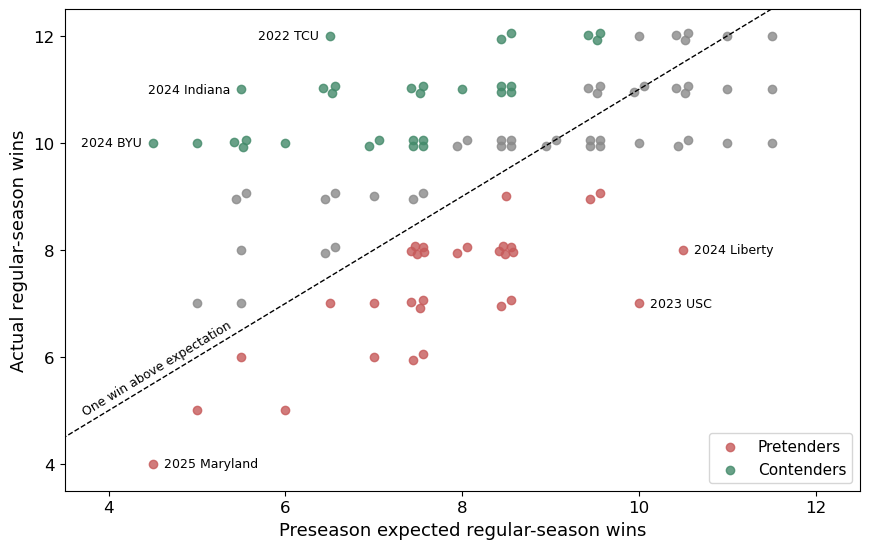

In [125]:
plot_seasons = undefeated_seasons.copy()
plot_seasons["plot_expected"] = plot_seasons["expected"].astype(float)
plot_seasons["plot_actual"] = plot_seasons["actual"].astype(float)
for _, points in plot_seasons.groupby(["expected", "actual"], sort=False):
    if len(points) == 1:
        continue
    angles = np.linspace(np.pi / 4, np.pi / 4 + 2 * np.pi, len(points), endpoint=False)
    offsets = 0.08 * np.column_stack([np.cos(angles), np.sin(angles)])
    plot_seasons.loc[points.index, "plot_expected"] += offsets[:, 0]
    plot_seasons.loc[points.index, "plot_actual"] += offsets[:, 1]
plot_seasons["plot_expected"] = plot_seasons["plot_expected"].clip(0, 12.5)
plot_seasons["plot_actual"] = plot_seasons["plot_actual"].clip(0, 12.5)

fig_performance, ax = plt.subplots(figsize=FIG_SIZE)
for group in scatter_order:
    subset = plot_seasons[plot_seasons["group"] == group]
    ax.scatter(
        subset["plot_expected"], subset["plot_actual"],
        color=group_colors[group],
        label=group if group != "Other" else "_nolegend_",
        alpha=0.8,
    )

label_points = [(4.5, 4), (4.5, 10), (10, 7), (10.5, 8), (6.5, 12), (5.5, 11)]
label_seasons = plot_seasons[
    plot_seasons[["expected", "actual"]].apply(tuple, axis=1).isin(label_points)
]
for _, overlapping_points in label_seasons.groupby(["expected", "actual"], sort=False):
    for label_index, (_, point) in enumerate(overlapping_points.iterrows()):
        label_on_right = point["group"] == "Pretenders" and point["actual"] < point["expected"]
        horizontal_offset = 8 + 75 * label_index if label_on_right else -8 - 75 * label_index
        ax.annotate(
            f"{int(point['season'])} {point['team']}",
            (point["plot_expected"], point["plot_actual"]),
            xytext=(horizontal_offset, 0),
            textcoords="offset points",
            ha="left" if label_on_right else "right", va="center",
            fontsize=9,
        )

line_x = [0, 12.5]
ax.plot(line_x, [x + 1 for x in line_x], color="black", linestyle="--", linewidth=1)
ax.text(3.75, 4.85, "One win above expectation", rotation=45, rotation_mode="anchor", 
        transform_rotates_text=True, fontsize=9, ha="left", va="bottom")
ax.set(xlim=(3.5, 12.5), ylim=(3.5, 12.5), xticks=np.arange(4, 13, 2), yticks=np.arange(4, 13, 2), 
       xlabel="Preseason expected regular-season wins", ylabel="Actual regular-season wins")
ax.legend(loc="lower right")
fig_performance.tight_layout()
plt.show()

In [126]:
def compare_group_fits(plot_data, outcome, fit_x, group_order):
    x = plot_data["opp_expected"].to_numpy()
    y = plot_data[outcome].to_numpy()
    group_indicators = np.column_stack([
        plot_data["group"].eq(group).to_numpy(dtype=float)
        for group in group_order
    ])
    shared_line = np.column_stack([np.ones(len(x)), x])
    separate_lines = np.column_stack([group_indicators, group_indicators * x[:, None]])
    shared_rank = np.linalg.matrix_rank(shared_line)
    separate_rank = np.linalg.matrix_rank(separate_lines)
    shared_coefficients = np.linalg.lstsq(shared_line, y, rcond=None)[0]
    separate_coefficients = np.linalg.lstsq(separate_lines, y, rcond=None)[0]
    shared_residuals = y - shared_line @ shared_coefficients
    separate_residuals = y - separate_lines @ separate_coefficients
    shared_rss = shared_residuals @ shared_residuals
    separate_rss = separate_residuals @ separate_residuals
    numerator_df = separate_rank - shared_rank
    denominator_df = len(y) - separate_rank
    f_stat = max(0, (shared_rss - separate_rss) / numerator_df) / (separate_rss / denominator_df)
    p_value = f_distribution.sf(f_stat, numerator_df, denominator_df)

    shared_df = len(y) - shared_rank
    common_fit = shared_coefficients[0] + shared_coefficients[1] * fit_x
    common_fit_se = np.sqrt(
        shared_rss / shared_df
        * (1 / len(y) + (fit_x - x.mean()) ** 2 / np.sum((x - x.mean()) ** 2))
    )
    confidence_margin = t_distribution.ppf(0.975, shared_df) * common_fit_se
    group_fits = [
        separate_coefficients[index]
        + separate_coefficients[len(group_order) + index] * fit_x
        for index in range(len(group_order))
    ]

    return common_fit, common_fit - confidence_margin, common_fit + confidence_margin, group_fits, p_value

Games plotted: 210
Red Pretender points: 104
Green Contender points: 106


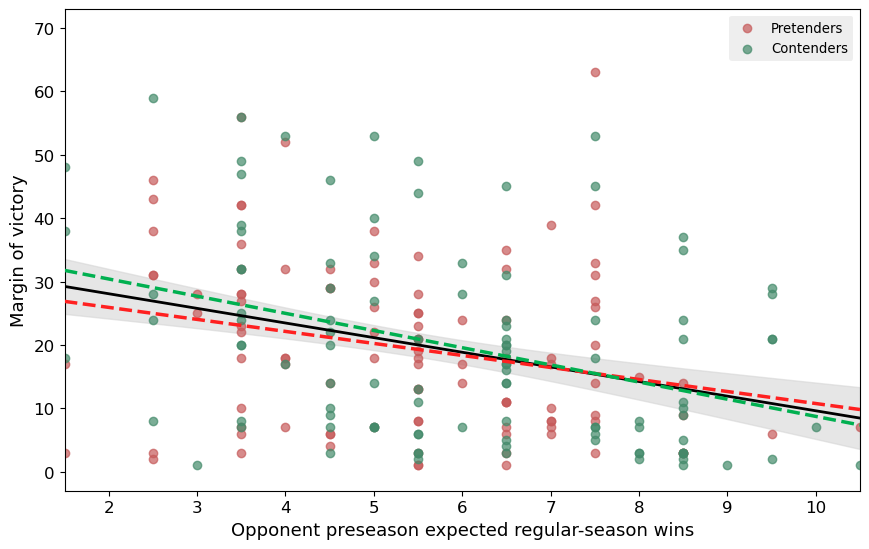

In [131]:
outcomes = [("margin", "Margin of victory"), ("team_score", "Points scored"), ("opponent_score", "Points against")]
periods = [("Weeks 0-5", None, None), ("Weeks 3-5", 3, 5)]
fit_colors = {"Pretenders": "#ff2020", "Contenders": "#00b050"}
x_min = grouped_games["opp_expected"].min()
x_max = grouped_games["opp_expected"].max()
fit_x = np.linspace(x_min, x_max, 100)
margin_data = grouped_games.dropna(subset=["opp_expected", "margin"])
print(f"Games plotted: {len(margin_data)}")
print(f"Red Pretender points: {margin_data['group'].eq('Pretenders').sum()}")
print(f"Green Contender points: {margin_data['group'].eq('Contenders').sum()}")

def draw_game_margins(margin_data, figsize):
    common_fit, confidence_lower, confidence_upper, group_fits, _ = compare_group_fits(
        margin_data, "margin", fit_x, group_order,
    )
    fig, ax = plt.subplots(figsize=figsize)
    ax.fill_between(
        fit_x, confidence_lower, confidence_upper,
        color="#d3d3d3", alpha=0.55, zorder=0,
    )
    ax.plot(fit_x, common_fit, color="black", linewidth=2, zorder=2)
    for group, group_fit in zip(group_order, group_fits):
        subset = margin_data[margin_data["group"] == group]
        ax.scatter(
            subset["opp_expected"], subset["margin"],
            color=group_colors[group], alpha=0.7, label=group,
        )
        ax.plot(
            fit_x, group_fit,
            color=fit_colors[group], linestyle="--", linewidth=2.5, zorder=3,
        )
    ax.set(
        xlim=(x_min, x_max), ylim=(-3, 73),
        xlabel="Opponent preseason expected regular-season wins",
        ylabel="Margin of victory",
    )
    ax.legend(
        loc="upper right", fontsize=9.5, frameon=True,
        facecolor="#eeeeee", edgecolor="none", framealpha=0.95,
    )
    fig.tight_layout()
    return fig

fig_game_margins = draw_game_margins(margin_data, FIG_SIZE)
fig_game_margins_thumb = draw_game_margins(margin_data, THUMBNAIL_SIZE)
plt.close(fig_game_margins_thumb)
plt.show()

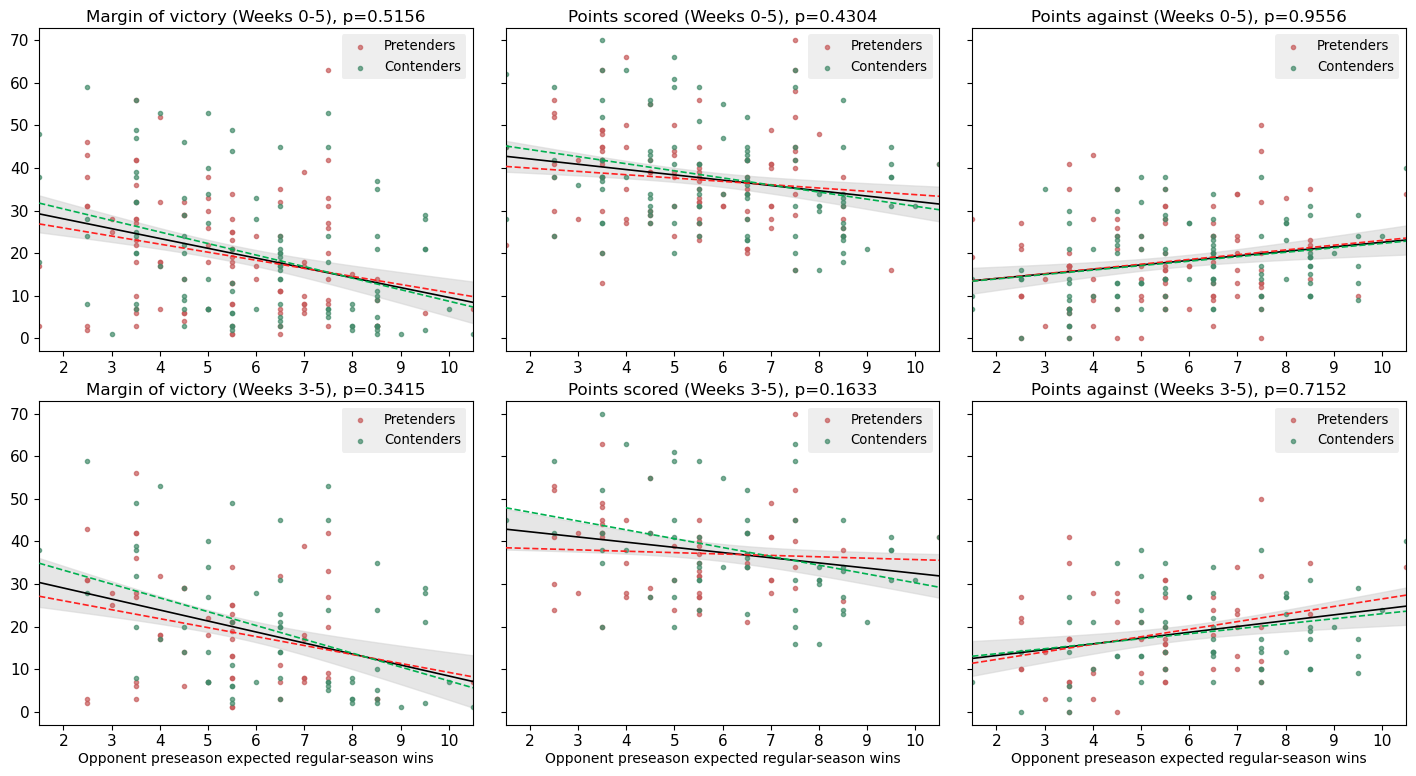

In [128]:
def draw_game_features(figsize):
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharey=True, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.06, hspace=0.02)

    for row, (period, first_week, last_week) in enumerate(periods):
        for col, (outcome, label) in enumerate(outcomes):
            plot_data = grouped_games.dropna(subset=["opp_expected", outcome])
            if first_week is not None:
                plot_data = plot_data[plot_data["week"].between(first_week, last_week)]

            ax = axes[row, col]
            common_fit, confidence_lower, confidence_upper, group_fits, p_value = compare_group_fits(
                plot_data, outcome, fit_x, group_order,
            )
            ax.fill_between(
                fit_x, confidence_lower, confidence_upper,
                color="#d3d3d3", alpha=0.55, zorder=0,
            )
            ax.plot(fit_x, common_fit, color="black", linewidth=1.2, zorder=2)

            for group, group_fit in zip(group_order, group_fits):
                subset = plot_data[plot_data["group"] == group]
                ax.scatter(
                    subset["opp_expected"], subset[outcome],
                    color=group_colors[group], alpha=0.7, s=9, label=group,
                )
                ax.plot(
                    fit_x, group_fit,
                    color=fit_colors[group], linestyle="--", linewidth=1.2, zorder=3,
                )

            ax.set(
                xlim=(x_min, x_max), ylim=(-3, 73),
                xlabel="" if row == 0 else "Opponent preseason expected regular-season wins",
                ylabel="",
            )
            ax.set_title(f"{label} ({period}), p={p_value:.4f}", fontsize=12, pad=4)
            ax.xaxis.label.set_size(10)
            ax.xaxis.labelpad = 2
            ax.tick_params(axis="both", labelsize=11)
            ax.legend(
                loc="upper right", fontsize=9.5, frameon=True,
                facecolor="#eeeeee", edgecolor="none", framealpha=0.95,
            )

    return fig

fig_games = draw_game_features((14, 7.6))
plt.show()

In [129]:
fig_performance.savefig(OUTPUT_DIR / "performance.png", dpi=EXPORT_DPI, bbox_inches="tight")
fig_game_margins.savefig(OUTPUT_DIR / "game-margins.png", dpi=EXPORT_DPI)
fig_game_margins_thumb.savefig(OUTPUT_DIR / "thumbnail-game-margins.png", dpi=THUMBNAIL_DPI)
fig_games.savefig(OUTPUT_DIR / "game-features.png", dpi=EXPORT_DPI)
thumbnail_image = plt.imread(OUTPUT_DIR / "thumbnail-game-margins.png")
assert thumbnail_image.shape[:2] == (630, 1100)

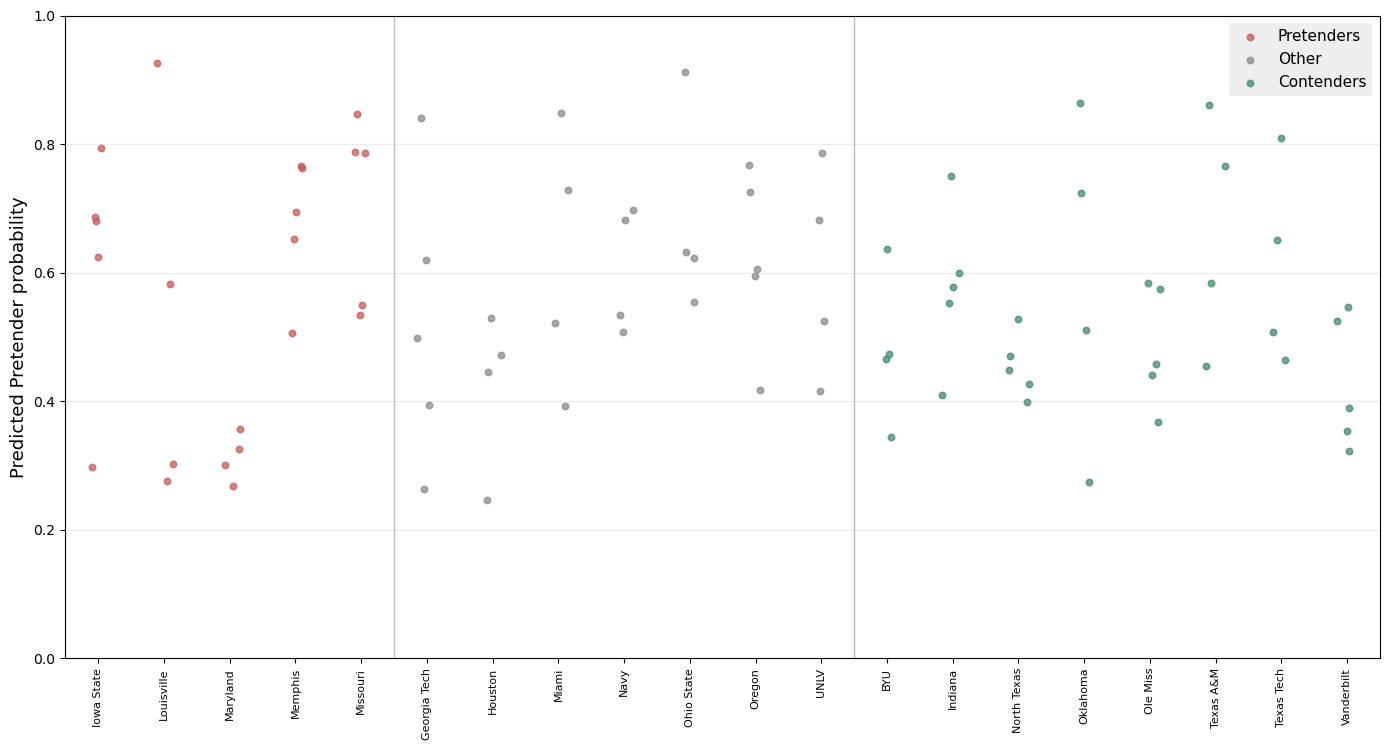

In [130]:
predictor_fields = [
    "expected", "opp_expected", "week", "site", "conference_game",
    "team_score", "opponent_score", "margin", "team_type", "opp_type",
]
categorical_fields = ["site", "conference_game", "team_type", "opp_type"]

training_games = undefeated_games.merge(
    undefeated_seasons[["team", "season", "group"]],
    on=["team", "season"], how="inner", validate="many_to_one",
)
training_games = training_games[
    training_games["season"].between(2021, 2024)
    & training_games["group"].isin(group_order)
].copy()
training_games["y"] = training_games["group"].eq("Pretenders").astype(int)

X_train = pd.get_dummies(training_games[predictor_fields], columns=categorical_fields)
red_flag_forest = RandomForestClassifier(n_estimators=500, random_state=2026)
red_flag_forest.fit(X_train, training_games["y"])

test_games = undefeated_games[undefeated_games["season"].eq(2025)].merge(
    undefeated_seasons.loc[
        undefeated_seasons["season"].eq(2025), ["team", "season", "group"]
    ],
    on=["team", "season"], how="inner", validate="many_to_one",
).copy()
X_2025 = pd.get_dummies(test_games[predictor_fields], columns=categorical_fields)
X_2025 = X_2025.reindex(columns=X_train.columns, fill_value=0)
test_games["pretender_probability"] = red_flag_forest.predict_proba(X_2025)[:, 1]

team_groups = test_games[["team", "group"]].drop_duplicates()
team_groups["group_order"] = team_groups["group"].map(
    {group: index for index, group in enumerate(scatter_order)}
)
team_groups = team_groups.sort_values(["group_order", "team"])
team_order = team_groups["team"].tolist()
ordered_groups = team_groups["group"].to_numpy()
team_x = {team: index for index, team in enumerate(team_order)}
jitter = np.random.default_rng(2026)

fig_2025_flags, ax = plt.subplots(figsize=(14, 7.6))
for group in scatter_order:
    group_games = test_games[test_games["group"].eq(group)]
    x = group_games["team"].map(team_x).to_numpy() + jitter.uniform(-0.16, 0.16, len(group_games))
    ax.scatter(
        x, group_games["pretender_probability"], color=group_colors[group],
        s=22, alpha=0.75, label=group,
    )

for boundary in np.flatnonzero(ordered_groups[1:] != ordered_groups[:-1]) + 1:
    ax.axvline(boundary - 0.5, color="#bdbdbd", linewidth=1)

ax.set(
    xlim=(-0.5, len(team_order) - 0.5), ylim=(0, 1),
    xticks=range(len(team_order)), ylabel="Predicted Pretender probability"
)
ax.set_xticklabels(team_order, rotation=90, fontsize=8)
ax.tick_params(axis="y", labelsize=10)
ax.legend(loc="upper right", frameon=True, facecolor="#eeeeee", edgecolor="none", framealpha=0.95)
ax.grid(axis="y", alpha=0.25)
fig_2025_flags.tight_layout()
plt.show()